In [ ]:
import pandas as pd

# Load the data

In [ ]:
data = pd.read_csv('Athena_survey_data.csv')
data.head()

,gender,state,age,income,imp.challenge,imp.unlocks,imp.customize,imp.difficulty,imp.characters,imp.storyline,...,freq.customize,freq.test.world,gg.game.presented,gg.maxprice,rank.WarriorGuild,rank.SeraphGuardians,rank.Evercrest,rank.DevilsGate,rank.Marksman,rank.QuestoftheTitan
0,male,IN,19,20000,4,7,5,7,5,3,...,3,1,Warrior Guild,42.0,2,3,6,4,1,5
1,male,OR,29,80000,5,7,1,4,2,4,...,1,3,Warrior Guild,59.0,3,1,6,4,2,5
2,male,MN,52,91000,4,3,3,4,5,7,...,2,3,Seraph Guardians,74.0,4,1,3,5,6,2
3,female,FL,20,24000,7,3,3,6,5,4,...,2,3,Warrior Guild,38.0,3,1,4,2,5,6
4,female,NM,33,64000,7,6,1,7,1,2,...,1,3,Evercrest,42.0,3,2,5,4,1,6


In [ ]:
data.columns

Index(['gender', 'state', 'age', 'income', 'imp.challenge', 'imp.unlocks',
       'imp.customize', 'imp.difficulty', 'imp.characters', 'imp.storyline',
       'imp.mastery', 'imp.backstory', 'imp.dominate', 'imp.completion',
       'imp.wealth', 'imp.fantasy', 'imp.items', 'imp.power', 'imp.offbeat',
       'imp.collect', 'enj.excitement', 'enj.destruction', 'enj.others',
       'enj.react', 'enj.duels', 'enj.strategy', 'enj.roleplay',
       'enj.competition', 'enj.decisions', 'enj.common.goal', 'enj.planning',
       'enj.immersion', 'enj.helping', 'enj.fast', 'enj.guns', 'enj.gore',
       'enj.blow.up', 'freq.explore', 'freq.experiment', 'freq.study',
       'freq.char.creation', 'freq.stats', 'freq.customize', 'freq.test.world',
       'gg.game.presented', 'gg.maxprice', 'rank.WarriorGuild',
       'rank.SeraphGuardians', 'rank.Evercrest', 'rank.DevilsGate',
       'rank.Marksman', 'rank.QuestoftheTitan'],
      dtype='object')

In [ ]:
for i, col_name in enumerate(data.columns):
    print(f"Column Number: {i}, Column Name: {col_name}")

Column Number: 0, Column Name: gender
Column Number: 1, Column Name: state
Column Number: 2, Column Name: age
Column Number: 3, Column Name: income
Column Number: 4, Column Name: imp.challenge
Column Number: 5, Column Name: imp.unlocks
Column Number: 6, Column Name: imp.customize
Column Number: 7, Column Name: imp.difficulty
Column Number: 8, Column Name: imp.characters
Column Number: 9, Column Name: imp.storyline
Column Number: 10, Column Name: imp.mastery
Column Number: 11, Column Name: imp.backstory
Column Number: 12, Column Name: imp.dominate
Column Number: 13, Column Name: imp.completion
Column Number: 14, Column Name: imp.wealth
Column Number: 15, Column Name: imp.fantasy
Column Number: 16, Column Name: imp.items
Column Number: 17, Column Name: imp.power
Column Number: 18, Column Name: imp.offbeat
Column Number: 19, Column Name: imp.collect
Column Number: 20, Column Name: enj.excitement
Column Number: 21, Column Name: enj.destruction
Column Number: 22, Column Name: enj.others
Col

# Question 3a

In [ ]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=884915d29ba74f29b94ef9384607cc1259615dd848ed89d29bd62a257e3f5dd4
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [ ]:
# bartlett's test of sphericity
# p is less thsn .05 so we can proceed
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value, p_value = calculate_bartlett_sphericity(data.iloc[:, 4:43])
print(f"Bartlett's Test of Sphericity p-value: {p_value}")

# KMO-test
# Greater than .6 so we can proceed
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all, kmo_model = calculate_kmo(data.iloc[:, 4:43])
print(f"KMO-test overall MSA: {kmo_model}")

Bartlett's Test of Sphericity p-value: 0.0
KMO-test overall MSA: 0.8849655809417178


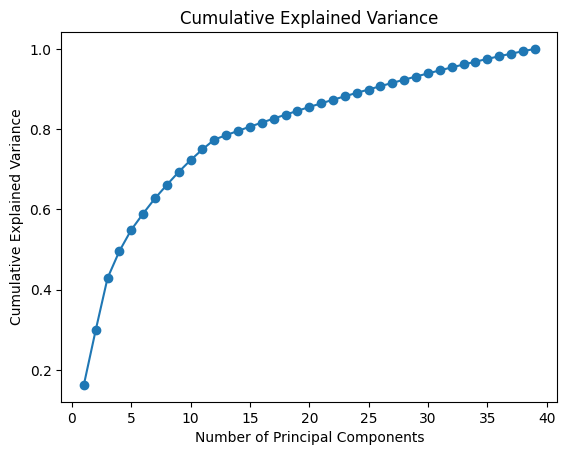

array([6.34167711, 5.32179927, 5.07026454, 2.6258309 , 2.06878021,
       1.57931906, 1.48223248, 1.30946173, 1.26229137, 1.14590765,
       1.04505825, 0.94606044, 0.43720979, 0.41547914, 0.40513987,
       0.39484501, 0.39146887, 0.37975227, 0.37518112, 0.37194134,
       0.35429991, 0.34945298, 0.33778697, 0.33291656, 0.32752052,
       0.32543625, 0.31801623, 0.3129943 , 0.30593932, 0.30281996,
       0.29386952, 0.28950754, 0.28322032, 0.27244156, 0.26975149,
       0.25702692, 0.24819963, 0.24276648, 0.22424768])

In [ ]:
# Determine the number of factors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardize the features (important for PCA)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:, 4:43])

# Create and fit the PCA model
pca = PCA()
pca.fit(data_scaled)

# Get the explained variance ratios
explained_variance_ratios = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_explained_variance = explained_variance_ratios.cumsum()

# Plot the explained variance ratios, want the factors to explain
# very roughly 70% or more of the variance
plt.plot(range(1, len(explained_variance_ratios) + 1), \
         cumulative_explained_variance, marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

pca.explained_variance_

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


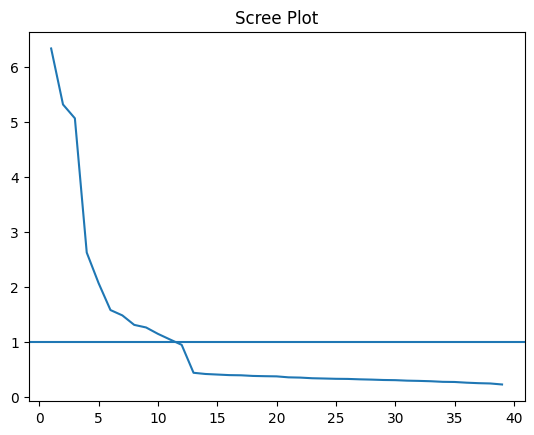

In [ ]:
from factor_analyzer import FactorAnalyzer
fa = FactorAnalyzer(rotation=None)
fa.fit(data_scaled)

eigenvalues, _ = fa.get_eigenvalues()

plt.plot(range(1, len(eigenvalues)+1), eigenvalues)
plt.axhline(1)
plt.title("Scree Plot")
plt.show()

In [ ]:
from factor_analyzer import Rotator
from sklearn.decomposition import FactorAnalysis

rotator = Rotator()

fa = FactorAnalysis(n_components=5)
fa.fit(data_scaled)
rotated_loading = rotator.fit_transform(fa.components_.T)

print("Rotated Factor Loadings:")
pd.DataFrame(rotated_loading, columns=['Factor 1', 'Factor 2', 'Factor 3', 'Factor 4', 'Factor 5'], index=data.columns[4:43])

Rotated Factor Loadings:


,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5
imp.challenge,-0.120746,-0.031725,0.114268,0.665228,-0.011088
imp.unlocks,-0.178833,-0.744374,0.032576,-0.119926,-0.339830
imp.customize,-0.164528,-0.050513,-0.450927,0.017254,0.173014
imp.difficulty,-0.116408,-0.048560,0.124056,0.658829,-0.003767
imp.characters,0.130021,0.210559,-0.605688,-0.046183,-0.123086
imp.storyline,0.139192,0.218776,-0.623396,-0.028792,-0.127117
imp.mastery,-0.071138,0.022598,0.041420,0.804417,-0.004706
imp.backstory,0.121740,0.211459,-0.609457,-0.057583,-0.134441
imp.dominate,0.065278,0.009708,0.013139,0.019537,0.720203
imp.completion,-0.162575,-0.753479,0.033621,-0.122257,-0.324485


In [ ]:
factor_scores = fa.transform(data_scaled)

In [ ]:
data['Action'] = factor_scores[:, 0]
data['Completion'] = factor_scores[:, 1]
data['Immersion'] = factor_scores[:, 2]
data['Mastery'] = factor_scores[:, 3]
data['Competition'] = factor_scores[:, 4]
data

,gender,state,age,income,imp.challenge,imp.unlocks,imp.customize,imp.difficulty,imp.characters,imp.storyline,...,rank.SeraphGuardians,rank.Evercrest,rank.DevilsGate,rank.Marksman,rank.QuestoftheTitan,Action,Completion,Immersion,Mastery,Competition
0,male,IN,19,20000,4,7,5,7,5,3,...,3,6,4,1,5,-0.512041,-1.462038,0.743537,-1.720729,0.371731
1,male,OR,29,80000,5,7,1,4,2,4,...,1,6,4,2,5,0.302112,-0.869455,0.425790,0.287975,2.101999
2,male,MN,52,91000,4,3,3,4,5,7,...,1,3,5,6,2,-0.672206,-0.197781,-1.465764,0.533336,-0.754902
3,female,FL,20,24000,7,3,3,6,5,4,...,1,4,2,5,6,-0.744312,1.725396,1.230582,-0.595647,0.479701
4,female,NM,33,64000,7,6,1,7,1,2,...,2,5,4,1,6,-0.562093,-0.606877,2.014080,1.065722,0.454713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2173,male,MA,28,54000,5,3,1,5,3,3,...,2,5,3,4,6,-0.118892,0.047903,1.443311,-1.154619,-1.023148
2174,male,NY,42,118000,3,7,3,3,6,3,...,1,3,5,4,2,-1.105530,-1.937928,0.256323,-0.674095,-0.968209
2175,female,MO,52,97000,6,5,1,5,3,2,...,2,6,3,1,5,-0.171520,-0.328825,1.928864,0.631811,-0.801812
2176,nonbinary,TX,22,33000,2,4,4,1,2,1,...,4,6,1,3,5,1.714697,0.145682,0.704185,-0.538005,0.778788


# Question 3b

/tmp/ipython-input-2351740597.py:6: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  hc = linkage(dissimilarity_matrix, method="ward")


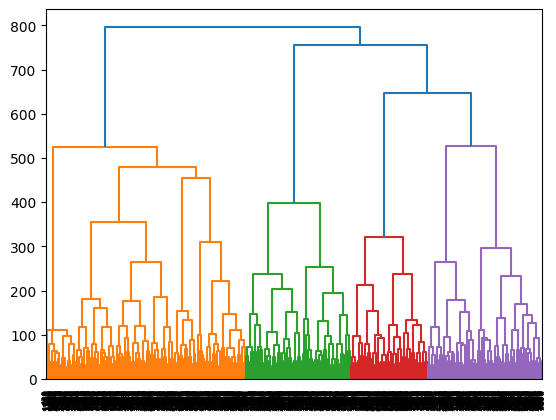

In [ ]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
dissimilarity_matrix = squareform(pdist(data[['Action', 'Completion', 'Immersion', 'Mastery', 'Competition']], metric='euclidean'))

# perform hierarchical clustering using Ward's method on this matrix
hc = linkage(dissimilarity_matrix, method="ward")

# plot the resulting dendrogram
dendrogram(hc, leaf_font_size=6)
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardize the features (important for PCA)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[['Action', 'Completion', 'Immersion', 'Mastery', 'Competition']])

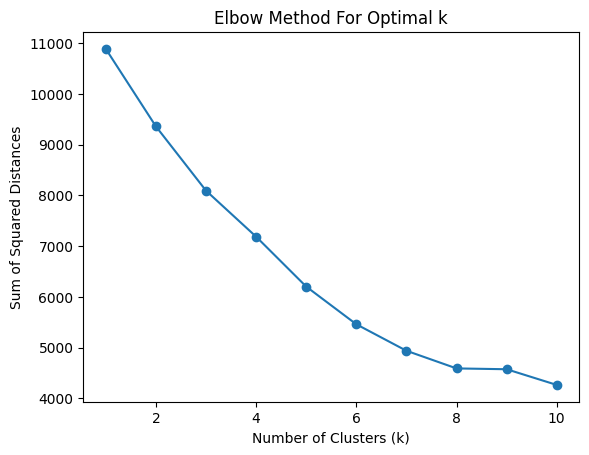

In [ ]:
from sklearn.cluster import KMeans

# Calculate the sum of squared distances for different values of k
sum_of_squared_distances = []
K_range = range(1, 11)  # You can adjust this range based on your problem
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto')
    kmeans.fit(data_scaled)
    sum_of_squared_distances.append(kmeans.inertia_)

# Plot the Elbow curve
plt.plot(K_range, sum_of_squared_distances, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Distances')
plt.show()

In [ ]:
# Step 2: Calculate the final cluster solution
kmeans = KMeans(n_clusters=4, random_state=11, n_init='auto')

# Add a new column with cluster assignment for each person
data['Cluster'] = kmeans.fit_predict(data[['Action', 'Completion', 'Immersion', 'Mastery', 'Competition']])
data

,gender,state,age,income,imp.challenge,imp.unlocks,imp.customize,imp.difficulty,imp.characters,imp.storyline,...,rank.Evercrest,rank.DevilsGate,rank.Marksman,rank.QuestoftheTitan,Action,Completion,Immersion,Mastery,Competition,Cluster
0,male,IN,19,20000,4,7,5,7,5,3,...,6,4,1,5,-0.512041,-1.462038,0.743537,-1.720729,0.371731,1
1,male,OR,29,80000,5,7,1,4,2,4,...,6,4,2,5,0.302112,-0.869455,0.425790,0.287975,2.101999,1
2,male,MN,52,91000,4,3,3,4,5,7,...,3,5,6,2,-0.672206,-0.197781,-1.465764,0.533336,-0.754902,3
3,female,FL,20,24000,7,3,3,6,5,4,...,4,2,5,6,-0.744312,1.725396,1.230582,-0.595647,0.479701,2
4,female,NM,33,64000,7,6,1,7,1,2,...,5,4,1,6,-0.562093,-0.606877,2.014080,1.065722,0.454713,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2173,male,MA,28,54000,5,3,1,5,3,3,...,5,3,4,6,-0.118892,0.047903,1.443311,-1.154619,-1.023148,2
2174,male,NY,42,118000,3,7,3,3,6,3,...,3,5,4,2,-1.105530,-1.937928,0.256323,-0.674095,-0.968209,1
2175,female,MO,52,97000,6,5,1,5,3,2,...,6,3,1,5,-0.171520,-0.328825,1.928864,0.631811,-0.801812,2
2176,nonbinary,TX,22,33000,2,4,4,1,2,1,...,6,1,3,5,1.714697,0.145682,0.704185,-0.538005,0.778788,0


In [ ]:
# Step 3: Interpret the K-means output
print("Cluster Centers:")
pd.DataFrame(kmeans.cluster_centers_, columns=['Action', 'Completion', 'Immersion', 'Mastery', 'Competition'], \
             index=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'], )

Cluster Centers:


,Action,Completion,Immersion,Mastery,Competition
Cluster 0,1.250188,-0.042305,-0.240719,0.294714,0.042888
Cluster 1,-0.441230,-1.203445,-0.194884,-0.327834,0.082759
Cluster 2,-0.266990,0.301500,1.245748,0.085897,-0.132381
Cluster 3,-0.537358,0.763806,-0.691418,-0.071222,0.007132


# Question 3c

### Cross-tab for gender and segment

In [ ]:
ct_gender = pd.crosstab(data['Cluster'], data['gender'], normalize='index') * 100
ct_gender_counts = pd.crosstab(data['Cluster'], data['gender'])

print(ct_gender.round(1))
print(ct_gender_counts)

gender   female  male  nonbinary
Cluster                         
0          36.5  62.7        0.7
1          54.4  44.6        1.0
2          40.5  58.3        1.2
3          52.2  47.8        0.0
gender   female  male  nonbinary
Cluster                         
0           201   345          4
1           271   222          5
2           211   304          6
3           318   291          0


### Average age and income per segment

In [ ]:
demo_summary = data.groupby('Cluster').agg({
    'age': 'mean',
    'income': 'mean'
})

print(demo_summary.round(2))

           age    income
Cluster                 
0        25.04  44967.27
1        32.53  60965.86
2        28.58  56222.65
3        25.79  43995.07


### Chi-square test for gender and cluster

In [ ]:
from scipy.stats import chi2_contingency

crosstab = pd.crosstab(data['Cluster'], data['gender'])

chi2, p, _, expected = chi2_contingency(crosstab)
print(f"Chi-squared value: {chi2}")
print(f"P-value: {p}")
print("Expected Values:")
pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns)

Chi-squared value: 55.696864508893086
P-value: 3.3520887599967665e-10
Expected Values:


gender,female,male,nonbinary
Cluster,,,
0,252.777778,293.434343,3.787879
1,228.878788,265.691460,3.429752
2,239.449495,277.962351,3.588154
3,279.893939,324.911846,4.194215


In [ ]:
contributions = (crosstab - expected) ** 2 / expected
print("\nChi-squared Contributions:")
contributions


Chi-squared Contributions:


gender,female,male,nonbinary
Cluster,,,
0,10.605910,9.061710,0.011879
1,7.751686,7.184814,0.718909
2,3.380144,2.439032,1.621168
3,5.187936,3.539462,4.194215


In [ ]:
def xtab(d1, d2):
    crosstab = pd.crosstab(index=d1, columns=d2)
    chi2, p, _, expected = chi2_contingency(crosstab)
    contributions = (crosstab - expected) ** 2 / expected

    # Create a multi-index DataFrame
    index = pd.MultiIndex.from_product([crosstab.index, ['Observed', 'Expected', 'Chi squared']])
    columns = pd.MultiIndex.from_product([crosstab.columns])

    df = pd.DataFrame(index=index, columns=columns)

    # Fill in the DataFrame
    df.loc[crosstab.index, 'Observed', :] = crosstab.values
    df.loc[crosstab.index, 'Expected', :] = expected.round(2)
    df.loc[crosstab.index, 'Chi squared', :] = contributions.values.round(2)

    print(f"Chi-squared value: {chi2}")
    print(f"P-value: {p}")
    return(df)

In [ ]:
xtab(data['Cluster'], data['gender'])

Chi-squared value: 55.696864508893086
P-value: 3.3520887599967665e-10


gender               female    male nonbinary
Cluster                                      
0       Observed        201     345         4
        Expected     252.78  293.43      3.79
        Chi squared   10.61    9.06      0.01
1       Observed        271     222         5
        Expected     228.88  265.69      3.43
        Chi squared    7.75    7.18      0.72
2       Observed        211     304         6
        Expected     239.45  277.96      3.59
        Chi squared    3.38    2.44      1.62
3       Observed        318     291         0
        Expected     279.89  324.91      4.19
        Chi squared    5.19    3.54      4.19

In [ ]:
from scipy.stats import f_oneway

groups = [data[data['Cluster'] == k]['age'] for k in sorted(data['Cluster'].unique())]
f_stat, p_age = f_oneway(*groups)

print("ANOVA p-value (age):", p_age)

ANOVA p-value (age): 5.36078867832343e-41


In [ ]:
groups_income = [data[data['Cluster'] == k]['income'] for k in sorted(data['Cluster'].unique())]
f_stat_inc, p_income = f_oneway(*groups_income)

print("ANOVA p-value (income):", p_income)

ANOVA p-value (income): 3.129829710662087e-23


In [ ]:
northeast = ['ME','NH','VT','MA','RI','CT','NY','NJ','PA']
midwest = ['OH','MI','IN','IL','WI','MN','IA','MO','ND','SD','NE','KS']
south = ['DE','MD','DC','VA','WV','NC','SC','GA','FL','KY','TN','AL','MS','AR','LA','OK','TX']
west = ['MT','ID','WY','CO','NM','AZ','UT','NV','WA','OR','CA','AK','HI']

In [ ]:
def state_to_region(state):
    if state in northeast:
        return 'Northeast'
    elif state in midwest:
        return 'Midwest'
    elif state in south:
        return 'South'
    elif state in west:
        return 'West'
    else:
        return 'Other'

data['region'] = data['state'].apply(state_to_region)

In [ ]:
ct_region = pd.crosstab(data['Cluster'], data['region'], normalize='index') * 100
ct_region.round(1)

region,Midwest,Northeast,South,West
Cluster,,,,
0,18.4,19.1,38.5,24.0
1,22.9,15.3,38.8,23.1
2,22.1,16.9,37.6,23.4
3,23.3,14.9,37.4,24.3


In [ ]:
from scipy.stats import chi2_contingency

crosstab = pd.crosstab(data['Cluster'], data['region'])

chi2, p, _, expected = chi2_contingency(crosstab)
print(f"Chi-squared value: {chi2}")
print(f"P-value: {p}")
print("Expected Values:")
pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns)

Chi-squared value: 7.948782991789551
P-value: 0.5393158159706788
Expected Values:


region,Midwest,Northeast,South,West
Cluster,,,,
0,119.191919,90.909091,209.343434,130.555556
1,107.922865,82.314050,189.550964,118.212121
2,112.907254,86.115702,198.305326,123.671717
3,131.977961,100.661157,231.800275,144.560606


In [ ]:
contributions = (crosstab - expected) ** 2 / expected
print("\nChi-squared Contributions:")
contributions


Chi-squared Contributions:


region,Midwest,Northeast,South,West
Cluster,,,,
0,2.776580,2.184091,0.033712,0.015981
1,0.342203,0.484331,0.062758,0.087281
2,0.038789,0.041230,0.026800,0.022597
3,0.761046,0.927249,0.062304,0.081830


In [ ]:
xtab(data['Cluster'], data['region'])

Chi-squared value: 7.948782991789551
P-value: 0.5393158159706788


region              Midwest Northeast   South    West
Cluster                                              
0       Observed        101       105     212     132
        Expected     119.19     90.91  209.34  130.56
        Chi squared    2.78      2.18    0.03    0.02
1       Observed        114        76     193     115
        Expected     107.92     82.31  189.55  118.21
        Chi squared    0.34      0.48    0.06    0.09
2       Observed        115        88     196     122
        Expected     112.91     86.12  198.31  123.67
        Chi squared    0.04      0.04    0.03    0.02
3       Observed        142        91     228     148
        Expected     131.98    100.66   231.8  144.56
        Chi squared    0.76      0.93    0.06    0.08

### Regression Analysis

In [ ]:
import statsmodels.api as sm

In [ ]:
X = pd.get_dummies(data[['gender']], drop_first=True)

X = pd.concat([X, data[['age','income']]], axis=1)

# Convert booleans → integers
X = X.astype(int)

# Make sure age & income are numeric
X[['age','income']] = X[['age','income']].apply(pd.to_numeric)

y = data['Story'].astype(int)

X = sm.add_constant(X)

In [ ]:
for k in sorted(data['Cluster'].unique()):

    print("\n" + "="*60)
    print(f"Logistic Regression: Cluster {k} vs Rest")
    print("="*60)

    # Create binary DV for this cluster
    y = (data['Cluster'] == k).astype(int)

    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        print(result.summary())

    except Exception as e:
        print(f"Model failed for Cluster {k}: {e}")


Logistic Regression: Cluster 0 vs Rest
                           Logit Regression Results                           
Dep. Variable:                Cluster   No. Observations:                 2178
Model:                          Logit   Df Residuals:                     2173
Method:                           MLE   Df Model:                            4
Date:                Tue, 24 Feb 2026   Pseudo R-squ.:                 0.03805
Time:                        21:04:16   Log-Likelihood:                -1183.9
converged:                       True   LL-Null:                       -1230.8
Covariance Type:            nonrobust   LLR p-value:                 2.189e-19
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0362      0.207     -0.175      0.861      -0.442       0.369
gender_male          0.5147      0.104      4.937      0.000       0.310 

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# Question 4a

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
correlation_value = data['age'].corr(data['gg.maxprice'])
print(f"Correlation between A and B: {correlation_value}")

Correlation between A and B: 0.6199735987185454


In [ ]:
correlation_value = data['income'].corr(data['gg.maxprice'])
print(f"Correlation between A and B: {correlation_value}")

Correlation between A and B: 0.8421995527465735


In [ ]:
for game in data['gg.game.presented'].unique():
    # Create a mask for respondents who were shown this specific game
    mask_game = data['gg.game.presented'] == game

    # Separate those with a price (training set) from those without (imputation set)
    train_df = data[mask_game & data['gg.maxprice'].notna()]
    missing_df = data[mask_game & data['gg.maxprice'].isna()]

    if not missing_df.empty:
        # Define features (Income and Age have the highest correlation with price)
        X_train = train_df[['income', 'age']]
        y_train = train_df['gg.maxprice']

        # Initialize and fit the model
        model = LinearRegression()
        model.fit(X_train, y_train)

        # Predict values for the missing rows
        X_missing = missing_df[['income', 'age']]
        predictions = model.predict(X_missing)

        # Fill the missing values in the main dataframe
        data.loc[missing_df.index, 'gg.maxprice'] = predictions

# Question 4b

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipython-input-1047990943.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cumulative_wtp = pd.concat([cumulative_wtp, pd.DataFrame({


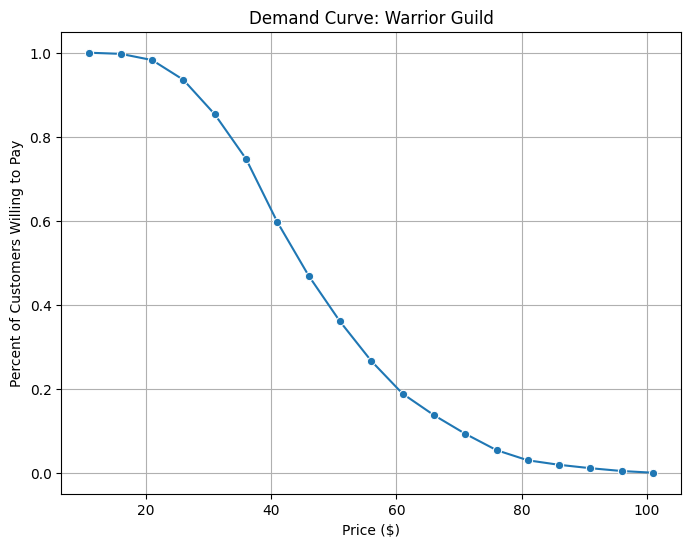

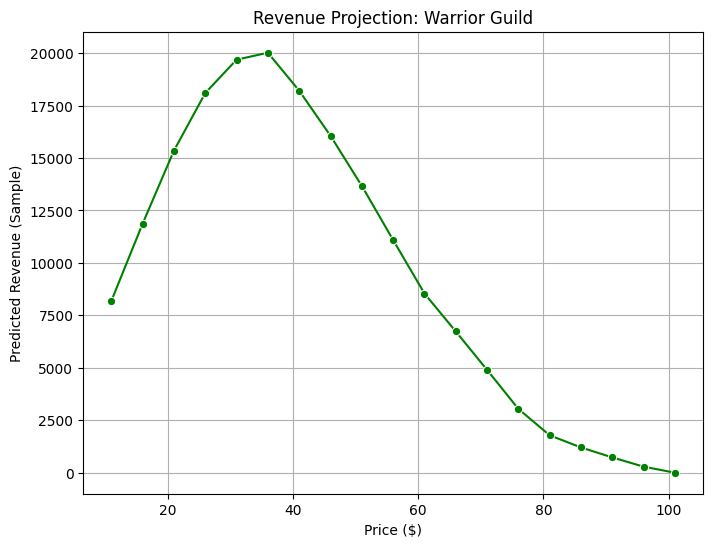

/tmp/ipython-input-1047990943.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cumulative_wtp = pd.concat([cumulative_wtp, pd.DataFrame({


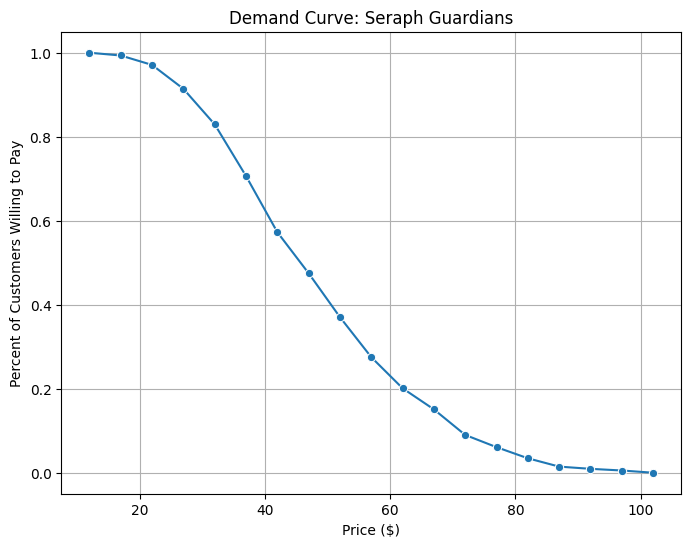

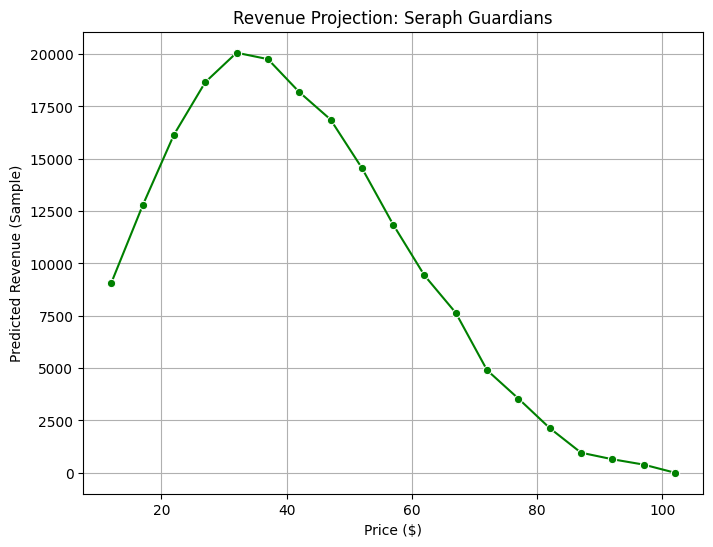

/tmp/ipython-input-1047990943.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cumulative_wtp = pd.concat([cumulative_wtp, pd.DataFrame({


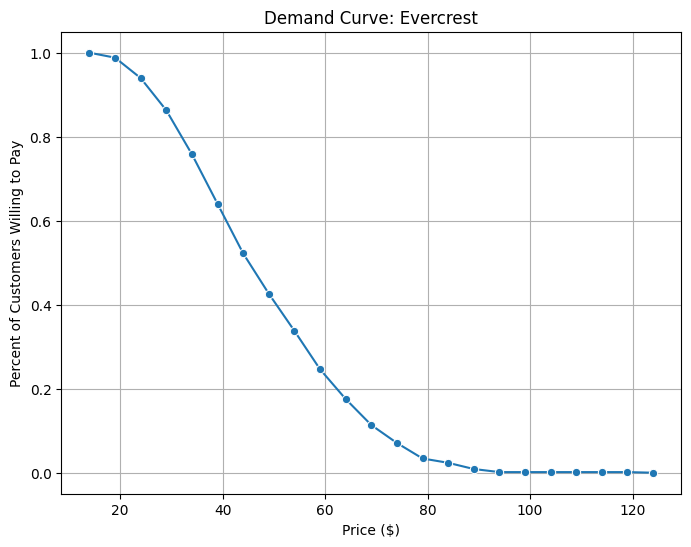

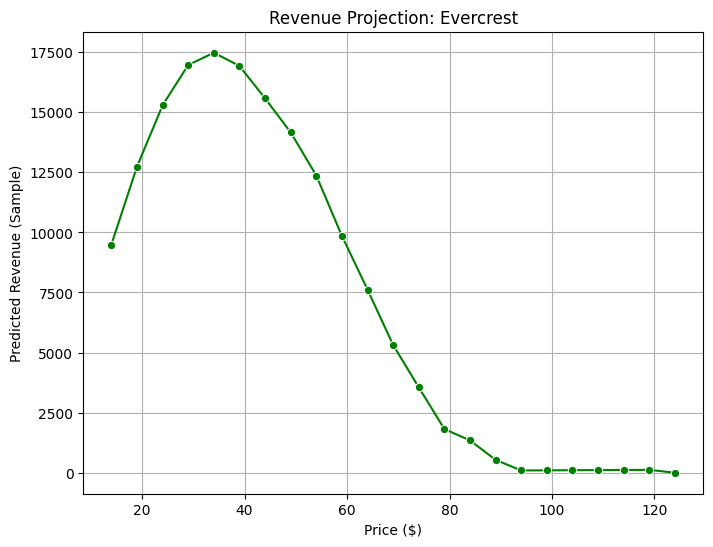

In [ ]:
for game in data['gg.game.presented'].unique():

    game_subset = data[data['gg.game.presented'] == game].copy()

    cumulative_wtp = pd.DataFrame(columns=['price', 'per_customers_wtp', 'pred_revenue'])

    for price in np.arange(min(game_subset['gg.maxprice']), max(game_subset['gg.maxprice']) + 5, 5):
        num_respondents_wtp = sum(game_subset['gg.maxprice'] >= price)
        cumulative_wtp = pd.concat([cumulative_wtp, pd.DataFrame({
        'price': [price],
        'per_customers_wtp': [num_respondents_wtp / len(game_subset)],
        'pred_revenue': [num_respondents_wtp * price]
    })], ignore_index=True)

    # Plot 1: Customers Willing to Pay vs. Price
    plt.figure(figsize=(8, 6))
    sns.lineplot(x='price', y='per_customers_wtp', data=cumulative_wtp, marker='o')
    plt.xlabel('Price ($)')
    plt.ylabel('Percent of Customers Willing to Pay')
    plt.title(f'Demand Curve: {game}')
    plt.grid(True)
    plt.show()

    # Plot 2: Predicted Revenue vs. Price
    plt.figure(figsize=(8, 6))
    sns.lineplot(x='price', y='pred_revenue', data=cumulative_wtp, marker='o', color='green')
    plt.xlabel('Price ($)')
    plt.ylabel('Predicted Revenue (Sample)')
    plt.title(f'Revenue Projection: {game}')
    plt.grid(True)
    plt.show()

# Question 4c

In [ ]:
import statsmodels.formula.api as smf

In [ ]:
for game in data['gg.game.presented'].unique():

    game_subset = data[data['gg.game.presented'] == game].copy()

    # make cluster categorical
    game_subset['Cluster'] = game_subset['Cluster'].astype('category')

    model = smf.ols("Q('gg.maxprice') ~ C(Cluster)", data=game_subset).fit()

    print("\n============================")
    print(f"Game: {game}")
    print("============================")

    print("\nMean WTP by Cluster:")
    print(game_subset.groupby('Cluster')['gg.maxprice'].mean().sort_values(ascending=False))

    print("\nRegression summary:")
    print(model.summary())


Game: Warrior Guild

Mean WTP by Cluster:
Cluster
2    48.347450
3    47.290547
1    46.960579
0    44.161392
Name: gg.maxprice, dtype: float64

Regression summary:
                            OLS Regression Results                            
Dep. Variable:       Q('gg.maxprice')   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     2.383
Date:                Tue, 24 Feb 2026   Prob (F-statistic):             0.0681
Time:                        22:08:59   Log-Likelihood:                -3108.2
No. Observations:                 744   AIC:                             6224.
Df Residuals:                     740   BIC:                             6243.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err       

/tmp/ipython-input-1371902364.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(game_subset.groupby('Cluster')['gg.maxprice'].mean().sort_values(ascending=False))
/tmp/ipython-input-1371902364.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(game_subset.groupby('Cluster')['gg.maxprice'].mean().sort_values(ascending=False))
/tmp/ipython-input-1371902364.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

# Question 5a

In [ ]:
# Market share = percent ranked #1
market_share = {}

for col in ['rank.WarriorGuild',
            'rank.SeraphGuardians',
            'rank.Evercrest',
            'rank.DevilsGate',
            'rank.Marksman',
            'rank.QuestoftheTitan']:

    game = col.replace('rank.', '')
    market_share[game] = (data[col] == 1).mean() * 100

market_share

{'WarriorGuild': np.float64(13.177226813590451),
 'SeraphGuardians': np.float64(50.04591368227732),
 'Evercrest': np.float64(9.77961432506887),
 'DevilsGate': np.float64(18.59504132231405),
 'Marksman': np.float64(2.295684113865932),
 'QuestoftheTitan': np.float64(6.106519742883379)}

In [ ]:
athena_share = {
    "Acquire Warrior Guild": market_share["WarriorGuild"],
    "Acquire Seraph Guardians": market_share["SeraphGuardians"],
    "Acquire Evercrest": market_share["Evercrest"],
    "Acquire none": 0
}

athena_share

{'Acquire Warrior Guild': np.float64(13.177226813590451),
 'Acquire Seraph Guardians': np.float64(50.04591368227732),
 'Acquire Evercrest': np.float64(9.77961432506887),
 'Acquire none': 0}

# Extra Credit

In [ ]:
p_one = 0.70
p_two = 0.30

rank_cols = [
    'rank.WarriorGuild',
    'rank.SeraphGuardians',
    'rank.Evercrest',
    'rank.DevilsGate',
    'rank.Marksman',
    'rank.QuestoftheTitan'
]

unit_share = {}

for col in rank_cols:
    game = col.replace('rank.', '')

    # Customers who buy only 1 game → #1 choice
    share_one = (data[col] == 1).mean()

    # Customers who buy 2 games → top 2 choices
    share_two = ((data[col] == 1) | (data[col] == 2)).mean()

    total_share = (p_one * share_one + p_two * share_two) * 100
    unit_share[game] = total_share

# Convert to table
unit_share_df = (
    pd.DataFrame({
        'Game': unit_share.keys(),
        'Simulated unit share (%)': [round(v, 2) for v in unit_share.values()]
    })
    .sort_values('Simulated unit share (%)', ascending=False)
)

unit_share_df

,Game,Simulated unit share (%)
1,SeraphGuardians,55.46
3,DevilsGate,23.68
0,WarriorGuild,19.50
5,QuestoftheTitan,13.17
2,Evercrest,11.97
4,Marksman,6.22


In [ ]:
athena_sim_share = {
    "Acquire Warrior Guild": unit_share["WarriorGuild"],
    "Acquire Seraph Guardians": unit_share["SeraphGuardians"],
    "Acquire Evercrest": unit_share["Evercrest"],
    "Acquire none": 0
}

{ k: round(v, 2) for k, v in athena_sim_share.items() }

{'Acquire Warrior Guild': np.float64(19.5),
 'Acquire Seraph Guardians': np.float64(55.46),
 'Acquire Evercrest': np.float64(11.97),
 'Acquire none': 0}